**PE - 3.12**

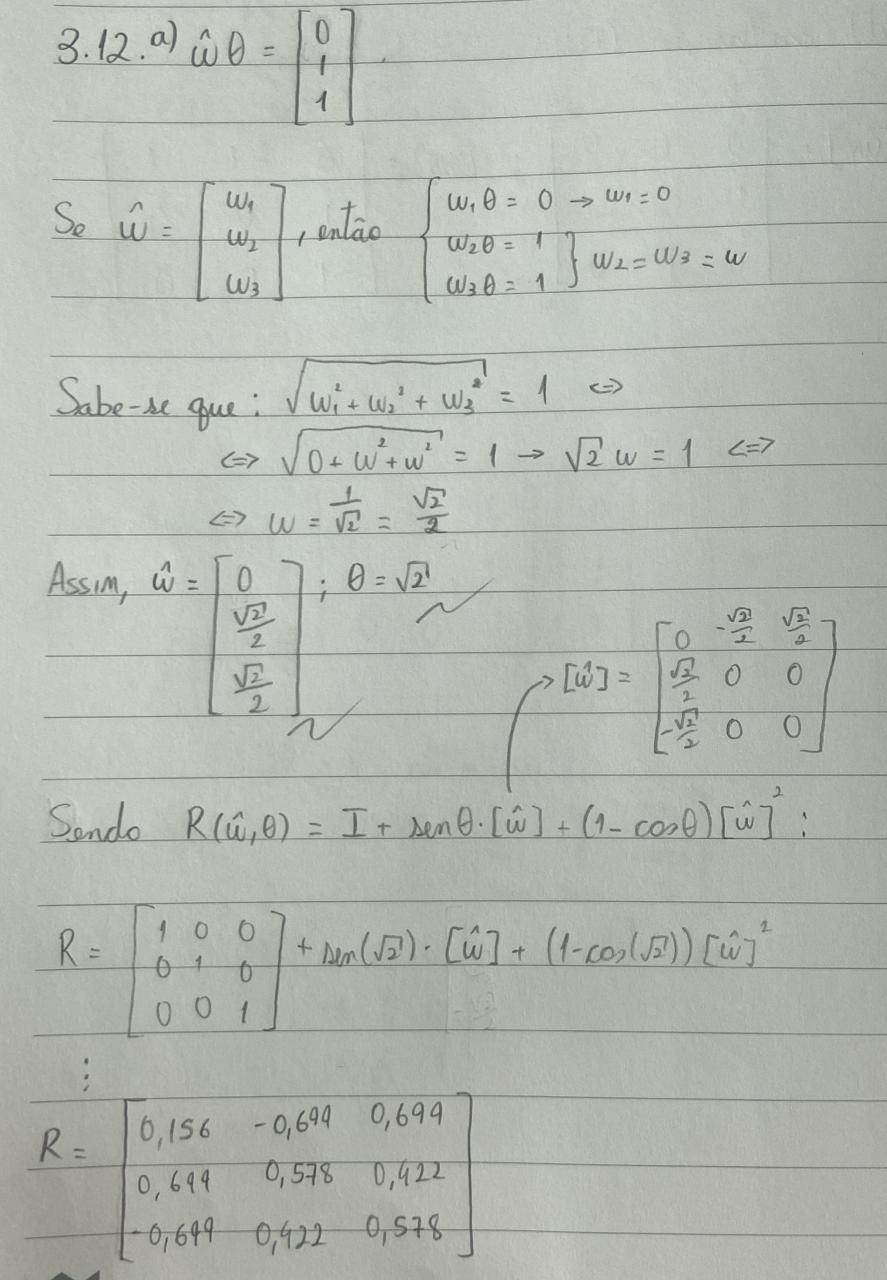
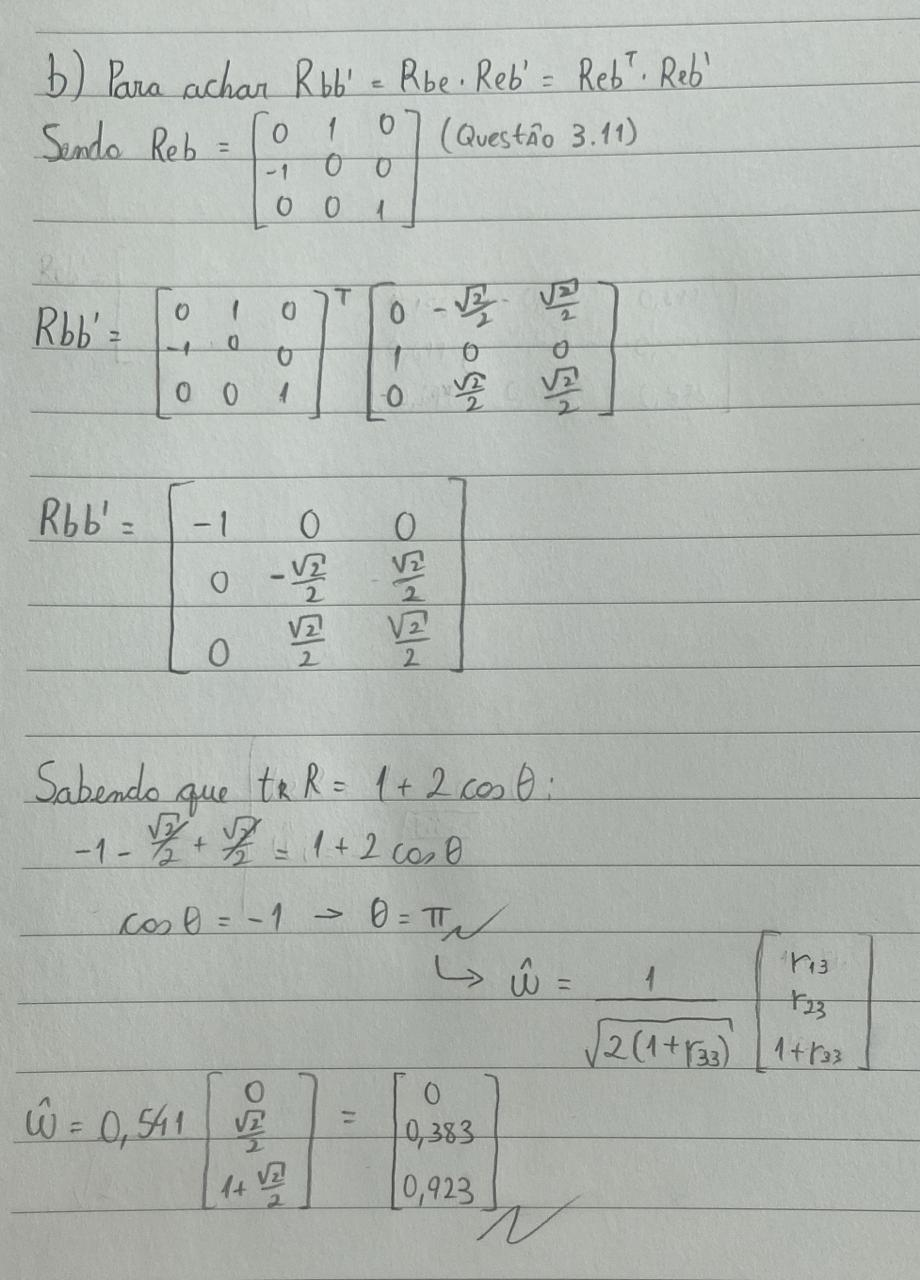

In [6]:
import numpy as np

In [12]:
def skew(v):
    return np.array([
        [ 0,    -v[2],  v[1]],
        [ v[2],  0,    -v[0]],
        [-v[1],  v[0],  0   ]
    ])

In [11]:
# a) Rotação a partir de Coordenadas Exponenciais
print("3.12 a)")

w_theta = np.array([0, 1, 1])

theta_a = np.linalg.norm(w_theta)
w_a = w_theta / theta_a

print(f"Theta: {theta_a:.3f} rad")
print(f"w_hat: {w_a.round(3)}")

W = skew(w_a)
I = np.eye(3)
R_a = I + np.sin(theta_a) * W + (1 - np.cos(theta_a)) * (W @ W)

print("Matriz R (Rodrigues):")
print(np.round(R_a, 3))


# b) Representação Eixo-Ângulo de R_bb'
print("\n3.12 b)")

# Matriz Reb dada na questão 3.11
R_eb = np.array([
    [ 0, 1, 0],
    [-1, 0, 0],
    [ 0, 0, 1]
])

sqrt2_2 = np.sqrt(2)/2
R_ebl = np.array([
    [0, -sqrt2_2,  sqrt2_2],
    [1,  0,        0      ],
    [0,  sqrt2_2,  sqrt2_2]
])

R_bbl = R_eb.T @ R_ebl
print("Matriz R_bb':")
print(np.round(R_bbl, 3))

trace = np.trace(R_bbl)
theta_b = np.arccos((trace - 1) / 2)
print(f"\nTheta: {theta_b:.3f} rad")

'''
Achar vetor w (Abordagem com Autovetores)

Quando theta = pi, o vetor w pode ser obtido por uma de 3 equações (3.58, 3.59 e 3.60
do livro Modern Robotics) distintas (a que apresentar solução possível). Para tornar o código mais generalista,
usei a propriedade de autovalores, uma vez que, qualquer ponto no eixo de
rotação não se move, a matriz de rotação R não altera o vetor do eixo (R * w = w).
Isso significa que w é, por definição, o autovetor associado ao autovalor lambda = 1.
'''

eigenvalues, eigenvectors = np.linalg.eig(R_bbl)
idx_lambda_1 = np.argmin(np.abs(eigenvalues - 1.0))
w_b = np.real(eigenvectors[:, idx_lambda_1])


print(f"w_b: \n{w_b.reshape(3,1).round(3)}")

3.12 a)
Theta: 1.414 rad
w_hat: [0.    0.707 0.707]
Matriz R (Rodrigues):
[[ 0.156 -0.698  0.698]
 [ 0.698  0.578  0.422]
 [-0.698  0.422  0.578]]

3.12 b)
Matriz R_bb':
[[-1.     0.     0.   ]
 [ 0.    -0.707  0.707]
 [ 0.     0.707  0.707]]

Theta: 3.142 rad
w_b: 
[[0.   ]
 [0.383]
 [0.924]]
